# Regression models
We will start with building regression models that are going to predict the net return of the loan. They can be more usefull than classification, since their objective incorporates the information of not only the probability of default, but also of the net return. 

## Evaluation framework
Before training, we should decide in which way we will evaluate the data. K-fold cross-validation seems to be a good chioce for reducing variance of metrics and will be used for both hyperparameter optimization and model selection. Holdout test set is used for final unbiased evaluation of a model on unseen data. 

When splitting we should decide, whether to do it randomly, or depending on time. Later approach would be better at representing real-world operational environment, yet if parameters are dependent on time, we may have a very biased test set. 

In [1]:
import sys
sys.path.append('..')
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from src.data_load import load_data

df = load_data()

In [3]:
df.shape

(1348068, 120)

<Axes: xlabel='issue_d'>

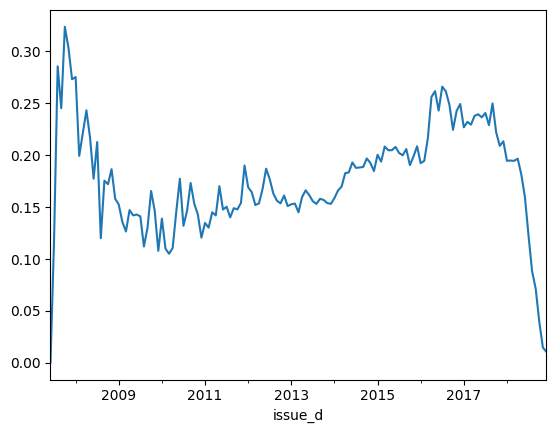

In [4]:
df.groupby('issue_d').is_default.mean().plot()

<Axes: xlabel='issue_d'>

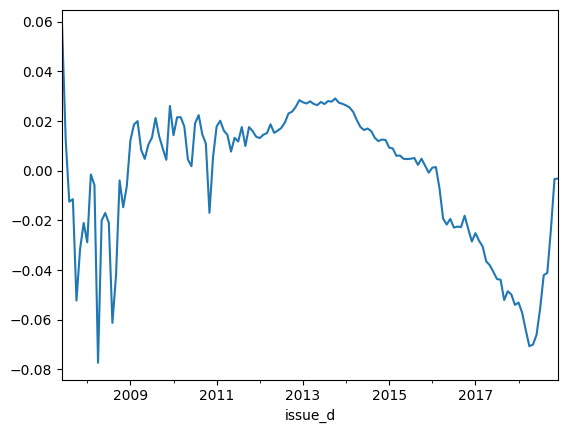

In [5]:
df.groupby('issue_d').ann_return.mean().plot()

<Axes: xlabel='last_pymnt_d'>

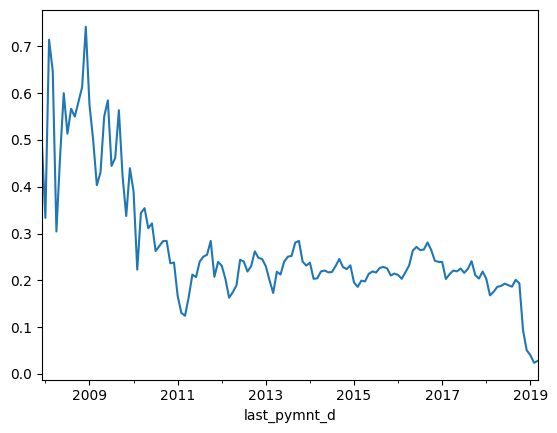

In [6]:
df.groupby('last_pymnt_d').is_default.mean().plot()

<Axes: xlabel='last_pymnt_d'>

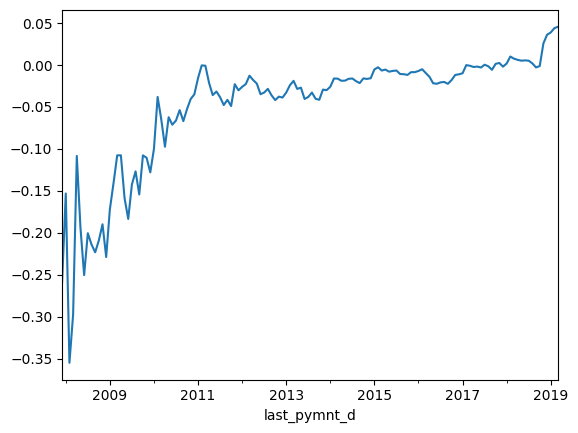

In [7]:
df.groupby('last_pymnt_d').ann_return.mean().plot()

We see that later years are biased, probably that people that want to close the loan fast, already did that, but defaulters didn't yet have time to default, so we should drop records with issue date after 2018. Moreover, we can clearly see that outcomes are not stationary in time, they depend on the overall state of the economy, so in order to have representative testing set, we should do random split, stratified by the issue year. Since we have class imbalances, we should also not forget to stratify by default status.


In [8]:
df = df[df.issue_d < '2018-01-01']
df.shape

(1291750, 120)

We have almost 1.3 million rows, so 10% = 130k rows will be quite representative for testing. Out of training set, 20% = 234k per fold in 5-fold cross-validation, which is also quite enough.

In [9]:
from sklearn.model_selection import train_test_split
from src.columns import FEATURE_COLS_CLEAN, REG_TARGET

df_train, df_test = train_test_split(df, test_size=0.1, random_state=42, stratify=df[['is_default', 'issue_y']])

In [10]:
X_train = df_train[FEATURE_COLS_CLEAN]
X_test = df_test[FEATURE_COLS_CLEAN]
y_train = df_train[REG_TARGET[0]]
y_test = df_test[REG_TARGET[0]]

## Base model: XGBoost
The idea is to first build a very strong predictor to establish the upper bound of prediction. That way we can meaningfully evaluate weaker models and see, how much predictive power can we retain. In turn this can dictate the choice of model, since simpler models can be faster or more interpretable. 

Outside of deep learning, tree boosting algorithms seem to have the greatest predictive power on tabular data. XGBoost has proven effective in reducing bias while controlling for overfitting. It's a boosting algorithm, which iteratively adds weak learners, which are in turn trained on the pseudo-residuals (gradient of the loss function) from previous iteration. Besides, it has built-in support for missing values and categoricals, regularisation parameters, it uses second-order gradients for better optimisation. 

LightGBM should be more effective for large datasets, but can be more prone to overfitting due to it's learning strategy. We will try it later and compare.

In [11]:
import xgboost as xgb

model = xgb.XGBRegressor(n_estimators=1000, enable_categorical=True, early_stopping_rounds=50)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=10)

[0]	validation_0-rmse:5137.43157
[10]	validation_0-rmse:4991.34692
[20]	validation_0-rmse:4981.08608
[30]	validation_0-rmse:4984.95060
[40]	validation_0-rmse:4986.82018
[50]	validation_0-rmse:4991.65558
[60]	validation_0-rmse:4996.71995
[70]	validation_0-rmse:5000.47002


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

Here we use early stopping in order to stop training when the test score stops improving. It is quite potent in the sense that it allows to prevent overfitting and reduce training time 

## Evaluation metrics

The point of modelling is to maximize net returns of approved loans under decision-making method. This means that we shouldn't approve neither too many nor too few loans, but find a balance. For regresson model, we should build a return-threshold curve and find it's maximum. Logically, the threshold should be 0, but there may be some variance that model doesn't explain, or bias, which may lead to slightly different thresholds. To make metric more interpretable, it should reflect the relative increase (or decrease) in total return compared to baseline strategy of approving all of the loans. 

In [12]:
import numpy as np

def build_curve(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    order = np.argsort(y_pred)[::-1]
    y_true = y_true[order]
    y_pred = y_pred[order]

    cumsum = np.cumsum(y_true)
    counts = np.arange(1, len(y_true) + 1)
    return pd.DataFrame({
        'threshold': y_pred,
        'sum': cumsum,
        'mean': cumsum / counts,
    })

In [14]:
y_pred = model.predict(X_test)
curve = build_curve(y_test, y_pred)
curve

,threshold,sum,mean
0,17619.140625,5.619392e+03,5619.392226
1,13646.710938,1.659477e+04,8297.384030
2,13476.020508,1.933331e+04,6444.436555
3,12526.815430,3.324414e+04,8311.035084
4,12483.911133,4.660601e+04,9321.202572
...,...,...,...
129170,-17098.187500,6.546083e+07,506.776541
129171,-17109.175781,6.543073e+07,506.539595
129172,-19991.181641,6.540750e+07,506.355793
129173,-20595.291016,6.542330e+07,506.474218


In [15]:
def curve_threshold(curve):
    return curve.threshold[curve['sum'].idxmax()]

def curve_max(curve):
    return curve['sum'].max()

def curve_base(curve):
    return curve['sum'].iloc[-1]

def curve_lift(curve):
    return curve_max(curve) / curve_base(curve)

def curve_net_improv(curve):
    return curve_max(curve) - curve_base(curve)

In [16]:
print('Threshold:', curve_threshold(curve))
print('Max:', curve_max(curve))
print('Base:', curve_base(curve))
print('Lift:', curve_lift(curve))
print('Net Improvement:', curve_net_improv(curve))

Threshold: -179.07709
Max: 109223127.30168945
Base: 65396720.74134304
Lift: 1.6701621436599017
Net Improvement: 43826406.56034641


In [17]:
import matplotlib.pyplot as plt
def plot_curve(curve):
    curve.plot(x='threshold', y=['sum', 'mean'], secondary_y='mean')
    plt.axvline(x=0, color='red', linestyle='--')
    threshold = curve_threshold(curve)
    plt.axvline(x=threshold, color='green', linestyle='--')
    print(f"Threshold: {threshold:.4f}\nLift: {curve_lift(curve):.4f} times\nNet improvement: ${curve_max(curve):e} - ${curve_base(curve):e} = ${curve_net_improv(curve):e}")

Threshold: -179.0771
Lift: 1.6702 times
Net improvement: $1.092231e+08 - $6.539672e+07 = $4.382641e+07


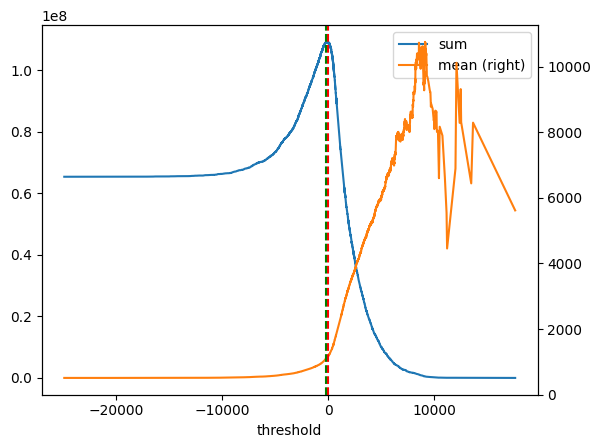

In [18]:
plot_curve(curve)

Here we see, that the optimal threshold for untuned model is almost 0, meaning that the model is not very biased. Yet the threshold is negative, meaning that approving small number of loans with slightly negative expected return may allow to catch some good loans. Approving all the loans (left side) still leads to a profit, which makes sense, since the dataset is conditioned on the fact that the loans had actually been approved.

Besides max return, we will use RMSE, which will explain the average error of the regression model, and r2, which will tell the proportion of variance explained by the model.

In [19]:
from sklearn.metrics import make_scorer, root_mean_squared_error, r2_score

def lift_score(y_true, y_pred):
    curve = build_curve(y_true, y_pred)
    return curve_lift(curve)


lift_scorer = make_scorer(lift_score, greater_is_better=True)

In [96]:
lift_scorer(model, X_test, y_test)

np.float64(1.6701621436599017)

In [97]:
print(f"RMSE={root_mean_squared_error(y_test, prediction):.4f}")
print(f"R^2={r2_score(y_test, prediction):.4f}")

RMSE=4981.1188
R^2=0.0975


This current not tuned model barely explains 10% of variance and has an average error of $4981, which is quite a lot, but may not be as consequential, since we're interested not necessarily in the correct prediction of net return, but rather in decision-making mechanism that leads to the greatest sum of returns. Besides, this should indicate that the data can have not much signal afterall, and it's ok.

Let's consider the relationship between our metric and some of other metrics, native to xgboost. We can't use maximum net profit as an objective function for xgboost, since it must be doubly differentiable, but we can try to use a proxy. Not only that, but proxy should be simply faster, since it's implemented with optmiizations in mind.

To do so let's do 50-fold cross validation and consider relationship of metrics across folds. Xgb implementation of cross-validation unfortunately doesn't give us raw metrics per fold, so we will use sklearn's, though it doesn't allow early stopping

In [19]:
from sklearn.model_selection import cross_validate

model = xgb.XGBRegressor(n_estimators=50, enable_categorical=True)

scores = cross_validate(
    model, X_train, y_train,
    cv=50,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'max_return': max_return_scorer,
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    }
)

<Axes: >

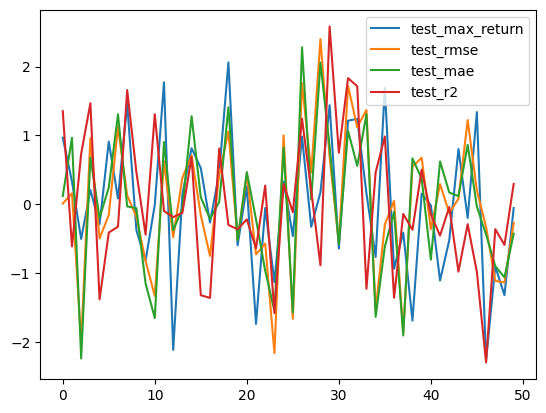

In [20]:
scores = pd.DataFrame(scores)
scores = (scores - scores.mean()) / scores.std()
scores.plot(y=['test_max_return', 'test_rmse', 'test_mae', 'test_r2'])

In [ ]:
scores[['test_max_return', 'test_rmse', 'test_mae', 'test_r2']].corr()

,test_max_return,test_rmse,test_mae,test_r2
test_max_return,1.000000,0.451505,0.425292,0.497822
test_rmse,0.451505,1.000000,0.935125,0.261251
test_mae,0.425292,0.935125,1.000000,0.142118
test_r2,0.497822,0.261251,0.142118,1.000000


Looks like they are similar to a certain extent. In limit, it makes sense - correct predictions lead to correct decision-making. Yet, in practice we care more about the sign of a return. Overall it seems like rmse can still be used as a proxy.

### XGBoost: tuning

We've already seen training time issues when comparing scoring methods, and they only deteriorate when tuning hyperparameters. There are some methods that can reduce time of tuning:
- use early stopping, rather than tuning number of estimators;
- tune on a stratified subset of original dataset;
- set a quite high learning rate for initial tuning: it should translate pretty well;
- use optuna for effective hyperparameter space search.

We propose finding optimal hyperparameter space on 10% stratified random sample of training data with high learning rate, then optimizing on whole training dataset with smaller search space, and finally tuning the model with optimal hyperparameters with quite low learning rate. 

In [15]:
df_sample = df_train.groupby(['is_default', 'issue_y']).sample(frac=0.1, random_state=42)
df_sample.shape

(116259, 120)

In [16]:
X_sample = df_sample[FEATURE_COLS_CLEAN]
y_sample = df_sample[REG_TARGET[0]]

We will use cross validation to acquire scores with lower variance, early stopping on lift score. In a sense, model is being trained to optimize RMSE, but stops according to lift metric. Search space is partially dictated by previous runs of optimization.

In [15]:
def lift_metric(prediction, dtrain):
    y = dtrain.get_label()
    return ('lift', lift_score(y, prediction))

In [ ]:
import optuna

def objective(trial):
    params = {
        'learning_rate': 0.15,
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'nthread': -1
    }

    dtune = xgb.DMatrix(X_sample, label=y_sample, enable_categorical=True)
    
    cv_results = xgb.cv(
        params,
        dtune,
        num_boost_round=1000,
        nfold=5,
        custom_metric=lift_metric,
        early_stopping_rounds=50,
        maximize=True,
        verbose_eval=10
    )
    
    return cv_results['test-lift-mean'].iloc[-1]

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

[I 2026-05-24 20:05:19,996] A new study created in memory with name: no-name-3780fa4f-e7e5-4151-9035-26c61d4c1af4


  0%|          | 0/100 [00:00<?, ?it/s]

[0]	train-rmse:5227.47843+6.96800	train-lift:1.63824+0.01981	test-rmse:5246.40024+31.55078	test-lift:1.53572+0.05731
[10]	train-rmse:4948.03578+6.74279	train-lift:1.88126+0.02534	test-rmse:5108.62241+25.19190	test-lift:1.59234+0.06030
[20]	train-rmse:4827.82480+7.75526	train-lift:1.99565+0.02166	test-rmse:5085.69696+24.99378	test-lift:1.61827+0.04925
[30]	train-rmse:4756.39805+6.78924	train-lift:2.06096+0.02473	test-rmse:5085.86897+28.16766	test-lift:1.61774+0.05212
[40]	train-rmse:4700.16290+4.14429	train-lift:2.11113+0.02558	test-rmse:5088.29558+24.71251	test-lift:1.61900+0.05404
[50]	train-rmse:4647.99887+4.41767	train-lift:2.15488+0.02408	test-rmse:5094.96439+25.98930	test-lift:1.62679+0.05718
[60]	train-rmse:4615.34811+4.82590	train-lift:2.18508+0.02223	test-rmse:5101.76502+24.86882	test-lift:1.61642+0.05019
[70]	train-rmse:4569.02991+5.69092	train-lift:2.22620+0.02046	test-rmse:5108.34837+26.24075	test-lift:1.60757+0.05408
[80]	train-rmse:4533.82735+3.06167	train-lift:2.26025+0.0

In [106]:
study_df = study.trials_dataframe()
study_df.sort_values(by='value', ascending=False).head(20)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,state
91,91,1.724338,2026-05-24 20:47:26.568641,2026-05-24 20:47:44.090901,0 days 00:00:17.522260,0.549233,0.688058,5,43,0.000682,3.605852,0.883437,COMPLETE
44,44,1.724090,2026-05-24 20:29:34.421611,2026-05-24 20:29:54.705731,0 days 00:00:20.284120,0.745277,0.731745,7,50,0.011488,1.661754,0.912202,COMPLETE
84,84,1.723904,2026-05-24 20:45:20.023091,2026-05-24 20:45:37.739342,0 days 00:00:17.716251,0.541033,0.425141,5,40,0.003017,1.641224,0.952876,COMPLETE
85,85,1.723664,2026-05-24 20:45:37.739342,2026-05-24 20:45:53.690972,0 days 00:00:15.951630,0.504484,0.420023,6,40,0.001902,1.888758,0.954940,COMPLETE
72,72,1.722098,2026-05-24 20:40:36.831369,2026-05-24 20:40:59.998139,0 days 00:00:23.166770,0.545621,0.901499,4,42,0.003065,0.026548,0.886327,COMPLETE
61,61,1.721918,2026-05-24 20:36:08.448976,2026-05-24 20:36:33.865133,0 days 00:00:25.416157,0.905870,0.941075,4,50,0.015754,0.142200,0.948185,COMPLETE
27,27,1.721721,2026-05-24 20:22:32.033941,2026-05-24 20:22:47.728585,0 days 00:00:15.694644,0.730730,1.223201,5,41,1.369366,0.031876,0.856933,COMPLETE
41,41,1.721289,2026-05-24 20:28:40.862310,2026-05-24 20:29:00.145365,0 days 00:00:19.283055,0.814909,1.173416,4,44,0.134159,0.328094,0.945034,COMPLETE
60,60,1.720992,2026-05-24 20:35:42.416092,2026-05-24 20:36:08.433359,0 days 00:00:26.017267,0.910193,1.103374,4,50,0.045466,0.134897,0.950611,COMPLETE
67,67,1.720718,2026-05-24 20:38:49.812897,2026-05-24 20:39:06.383042,0 days 00:00:16.570145,0.695119,0.179304,6,44,0.044272,4.740806,0.884893,COMPLETE


In [124]:
study_df.sort_values(by='value', ascending=False).head(5).filter(regex='^params_').agg(['min', 'max', 'mean'])

,params_colsample_bytree,params_gamma,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample
min,0.504484,0.420023,4.0,40.0,0.000682,0.026548,0.883437
max,0.745277,0.901499,7.0,50.0,0.011488,3.605852,0.954940
mean,0.577130,0.633293,5.4,43.0,0.004031,1.764827,0.917956


Now that we know the general area, we can try to calibrate parameters on the whole dataset with fewer trials.

In [125]:
import optuna
def objective(trial):
    params = {
        'learning_rate': 0.3,
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 40, 60),
        'subsample': trial.suggest_float('subsample', 0.8, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.85),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1e-2, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 4, log=True),
        'gamma': trial.suggest_float('gamma', 0.4, 1),
        'nthread': -1
    }

    dtune = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
    
    cv_results = xgb.cv(
        params,
        dtune,
        num_boost_round=1000,
        nfold=5,
        custom_metric=lift_metric,
        early_stopping_rounds=50,
        maximize=True,
        verbose_eval=10
    )
    
    return cv_results['test-lift-mean'].iloc[-1]

study_whole = optuna.create_study(direction='maximize')
study_whole.optimize(objective, n_trials=20, show_progress_bar=True)

[I 2026-05-24 21:03:33,722] A new study created in memory with name: no-name-b93bab6a-9b12-4a94-a02f-8797c8b36919


  0%|          | 0/20 [00:00<?, ?it/s]

[0]	train-rmse:5215.78477+3.58486	train-lift:1.60103+0.00418	test-rmse:5216.10666+15.00654	test-lift:1.60373+0.01983
[10]	train-rmse:5043.84168+3.74709	train-lift:1.71514+0.00558	test-rmse:5056.57416+14.96093	test-lift:1.69510+0.02102
[20]	train-rmse:5006.07186+3.14752	train-lift:1.75961+0.00712	test-rmse:5029.88171+15.44509	test-lift:1.72502+0.02438
[30]	train-rmse:4984.71984+3.32003	train-lift:1.78355+0.00630	test-rmse:5021.27536+15.39203	test-lift:1.73115+0.02204
[40]	train-rmse:4968.37455+4.35127	train-lift:1.80421+0.00485	test-rmse:5016.89451+15.47087	test-lift:1.73708+0.02350
[50]	train-rmse:4953.72459+3.79838	train-lift:1.82091+0.00527	test-rmse:5012.40831+16.56396	test-lift:1.74290+0.02324
[60]	train-rmse:4943.80110+4.22709	train-lift:1.83379+0.00433	test-rmse:5011.23694+16.59029	test-lift:1.74312+0.02276
[70]	train-rmse:4936.09522+4.76751	train-lift:1.84277+0.00452	test-rmse:5009.48146+16.97463	test-lift:1.74719+0.02136
[80]	train-rmse:4928.28181+4.97638	train-lift:1.85144+0.0

In [126]:
study_whole.trials_dataframe().sort_values(by='value', ascending=False)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,state
3,3,1.758498,2026-05-24 21:20:20.428144,2026-05-24 21:28:14.471172,0 days 00:07:54.043028,0.528784,0.826542,4,57,0.004293,0.652296,0.834013,COMPLETE
0,0,1.756031,2026-05-24 21:03:33.735416,2026-05-24 21:11:11.938264,0 days 00:07:38.202848,0.667039,0.845962,4,58,0.004523,0.345657,0.940189,COMPLETE
12,12,1.754506,2026-05-24 22:07:41.497088,2026-05-24 22:15:06.014429,0 days 00:07:24.517341,0.628650,0.927150,4,56,0.009582,3.962743,0.869109,COMPLETE
19,19,1.752455,2026-05-24 22:50:20.816545,2026-05-24 22:59:08.895059,0 days 00:08:48.078514,0.553024,0.707443,4,49,0.001848,0.036747,0.954267,COMPLETE
10,10,1.750573,2026-05-24 21:54:59.933344,2026-05-24 22:01:23.068671,0 days 00:06:23.135327,0.763969,0.634974,4,60,0.001017,0.002216,0.811474,COMPLETE
11,11,1.749907,2026-05-24 22:01:23.124816,2026-05-24 22:07:41.451418,0 days 00:06:18.326602,0.725862,0.835430,4,60,0.001231,0.150480,0.849173,COMPLETE
14,14,1.749152,2026-05-24 22:21:52.917032,2026-05-24 22:30:00.020436,0 days 00:08:07.103404,0.514071,0.982614,4,53,0.000575,0.080307,0.961182,COMPLETE
6,6,1.747914,2026-05-24 21:36:29.813850,2026-05-24 21:40:36.649363,0 days 00:04:06.835513,0.548433,0.843908,6,49,0.003220,1.071285,0.908607,COMPLETE
16,16,1.745820,2026-05-24 22:34:42.176116,2026-05-24 22:41:26.840760,0 days 00:06:44.664644,0.794303,0.650418,4,51,0.000359,3.743311,0.837613,COMPLETE
15,15,1.745338,2026-05-24 22:30:00.074785,2026-05-24 22:34:42.125502,0 days 00:04:42.050717,0.844741,0.783824,5,58,0.006479,0.019144,0.891081,COMPLETE


Learning on the whole dataset with higher learning rate, we still get better lift, as it becomes more representable. Trees become shallower with max depth 4 being optimal. 

In [127]:
xgb_params = {
    'colsample_bytree': 0.62,
    'gamma': 0.84,
    'max_depth': 4,
    'min_child_weight': 58,
    'reg_alpha': 0.0045,
    'reg_lambda': 0.65,
    'subsample': 0.86,
}

It's necessarily an optimistic parameter, though cross-validation has mitigated part of that, but it is enough for us to know the general area of optimal parameters. Early stopping will control overfitting.

### XGBoost: model evaluation

In [130]:
def custom_metric(predit, dtrain):
    y = dtrain.get_label()
    return [('r2', r2_score(y, predit)), ('lift', lift_score(y, predit))]

First we will use crosss-validation to have a more robust estimate of metrics

In [131]:
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)

params = {
    'eval_metric': ['rmse'],
    'learning_rate': 0.03
}

params.update(xgb_params)

xgb_cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=2000,
    nfold=5,
    custom_metric=custom_metric,
    early_stopping_rounds=50,
    maximize=True,
    verbose_eval=10
)

[0]	train-rmse:5296.90538+3.70722	train-r2:0.00398+0.00002	train-lift:1.60095+0.00397	test-rmse:5296.92297+14.90831	test-r2:0.00396+0.00004	test-lift:1.60466+0.01966
[10]	train-rmse:5224.09486+3.68960	train-r2:0.03118+0.00017	train-lift:1.60647+0.00883	test-rmse:5224.75105+15.05360	test-r2:0.03092+0.00036	test-lift:1.60294+0.02078
[20]	train-rmse:5175.71591+3.64343	train-r2:0.04904+0.00018	train-lift:1.64409+0.00967	test-rmse:5176.91605+15.09930	test-r2:0.04859+0.00059	test-lift:1.64046+0.02161
[30]	train-rmse:5144.65555+3.68116	train-r2:0.06042+0.00020	train-lift:1.64901+0.00899	test-rmse:5146.79173+15.13746	test-r2:0.05963+0.00080	test-lift:1.64401+0.02106
[40]	train-rmse:5120.61718+3.75231	train-r2:0.06918+0.00027	train-lift:1.66175+0.00683	test-rmse:5123.39357+15.02598	test-r2:0.06816+0.00092	test-lift:1.65593+0.02253
[50]	train-rmse:5101.59909+3.60193	train-r2:0.07608+0.00030	train-lift:1.67864+0.00610	test-rmse:5105.24732+15.08949	test-r2:0.07475+0.00102	test-lift:1.67270+0.02266

In [132]:
xgb_cv_results.iloc[-1]

train-rmse-mean    4897.640284
train-rmse-std        3.489674
test-rmse-mean     4988.940529
test-rmse-std        15.286950
train-r2-mean         0.148476
train-r2-std          0.000468
train-lift-mean       1.896655
train-lift-std        0.006809
test-r2-mean          0.116423
test-r2-std           0.001651
test-lift-mean        1.784079
test-lift-std         0.024594
Name: 1662, dtype: float64

Deviations are quite low, estimates are relatively stable

0.116 explained variance with RMSE of 4897 and lift of 1.78 times, quite similar train and test scores, slow learning does its thing. Finally let's evaluate on test set.

### XGBoost: final evaluation

In [136]:
xgb_model = xgb.XGBRegressor(
    **xgb_params,
    n_estimators=2000,
    learning_rate=0.03,
    enable_categorical=True,
    eval_metric=lift_score,
    callbacks=[xgb.callback.EarlyStopping(rounds=50, maximize=True, save_best=True)]
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=10
)

[0]	validation_0-rmse:5233.06174	validation_0-lift_score:1.55133
[10]	validation_0-rmse:5161.52792	validation_0-lift_score:1.55314
[20]	validation_0-rmse:5114.56040	validation_0-lift_score:1.58432
[30]	validation_0-rmse:5084.58832	validation_0-lift_score:1.58431
[40]	validation_0-rmse:5062.15531	validation_0-lift_score:1.59963
[50]	validation_0-rmse:5044.89017	validation_0-lift_score:1.61869
[60]	validation_0-rmse:5032.26117	validation_0-lift_score:1.63254
[70]	validation_0-rmse:5023.34155	validation_0-lift_score:1.63773
[80]	validation_0-rmse:5015.28424	validation_0-lift_score:1.64785
[90]	validation_0-rmse:5007.65671	validation_0-lift_score:1.65743
[100]	validation_0-rmse:5002.59349	validation_0-lift_score:1.66465
[110]	validation_0-rmse:4997.19237	validation_0-lift_score:1.67000
[120]	validation_0-rmse:4992.79023	validation_0-lift_score:1.67471
[130]	validation_0-rmse:4988.64837	validation_0-lift_score:1.68013
[140]	validation_0-rmse:4985.95838	validation_0-lift_score:1.68293
[150]	

XGBRegressor(base_score=None, booster=None,
             callbacks=[<xgboost.callback.EarlyStopping object at 0x00000190293DD3F0>],
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.62, device=None, early_stopping_rounds=None,
             enable_categorical=True,
             eval_metric=<function lift_score at 0x0000019023F77520>,
             feature_types=None, feature_weights=None, gamma=0.84,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=58, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=2000, n_jobs=None,
             num_parallel_tree=None, ...)

Threshold: -130.3754
Lift: 1.7214 times
Net improvement: $1.125736e+08 - $6.539672e+07 = $4.717687e+07


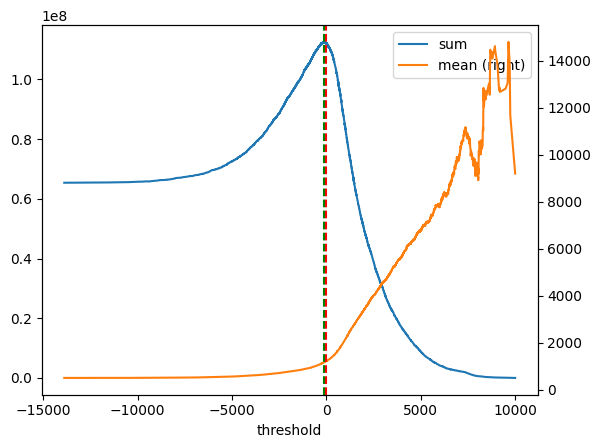

In [157]:
xgb_prediction = xgb_model.predict(X_test)
xgb_curve = build_curve(y_test, xgb_prediction)
plot_curve(xgb_curve)

This model has a slightly lower threshold, than 0, and leads to an improvement of 1.721 times compared to 1.67 times with default parameters for addtional $3.3m return, so model accuracy translates into real monetary value.

In [159]:
xgb_prediction_train = xgb_model.predict(X_train)
print(f"Train rmse=${root_mean_squared_error(xgb_prediction_train, y_train)}")
print(f"Test rmse=${root_mean_squared_error(xgb_prediction, y_test)}")

Train rmse=$4952.770403143408
Test rmse=$4948.05578888136


In [161]:
print(f"Train r2={r2_score(y_train, xgb_prediction_train)}")
print(f"Test r2={r2_score(y_test, xgb_prediction)}")

Train r2=0.1291984670925702
Test r2=0.10946358706649684


Model explains 10.9% of variance on test dataset and has a prediction error of around $4948. Train and test scores are not very divergent proving little overfitting

In [162]:
pd.Series(xgb_model.get_booster().get_score(importance_type='gain')).sort_values(ascending=False).head(20)

issue_y                  2.961843e+10
all_util                 2.220698e+10
open_rv_24m              2.084046e+10
mort_acc                 1.604479e+10
inq_last_12m             1.426733e+10
mths_since_rcnt_il       1.375129e+10
home_ownership           1.230759e+10
open_act_il              1.229617e+10
term                     1.102919e+10
acc_open_past_24mths     1.076329e+10
loan_amnt                8.566783e+09
tot_hi_cred_lim          8.153782e+09
avg_cur_bal              7.370154e+09
cr_line_y                6.786107e+09
issue_m                  5.769140e+09
num_tl_op_past_12m       5.505718e+09
total_bc_limit           4.350381e+09
annual_inc               4.227760e+09
mths_since_recent_inq    4.201970e+09
fico_range_low           4.054542e+09
dtype: float64

Looks like splitting by issue year, credit utilization, number of revolving trades, number of mortage accounts, number of inquiries, months since recent installmenet account open and home ownership type lead to high gain, explaining much of the variance. So state of economy, credit utilisation and number of revolving trades seem be good at splitting returns into group, which makes sense. In operation requirements issue_y is going to always be higher than split point, but that way we can cut out different economic regime associated with earlier yeasr.

Text(0, 0.5, 'prediction')

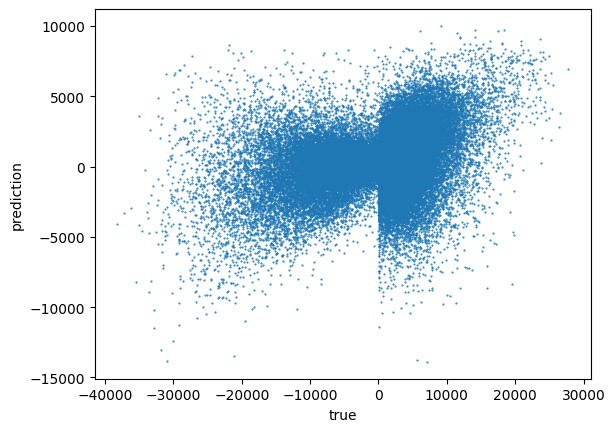

In [163]:
plt.plot(y_test, xgb_prediction, 'o', markersize=0.5)
plt.xlabel('true')
plt.ylabel('prediction')

Predictions seem to be clearly separated. Mostly because true labels are clearly split between positive loans with small returns and defaults with the mean of around -10k. Overall it seems like model tries to explain variance, especially with positive loans, but struggles a lot. Residual plot can explain the relationship more.

Text(0, 0.5, 'residuals')

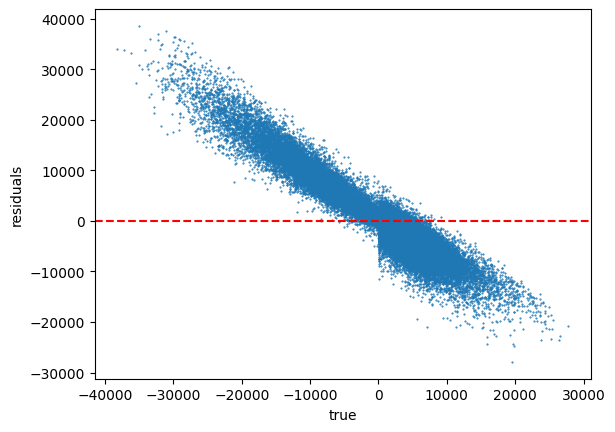

In [164]:
plt.plot(y_test, xgb_prediction - y_test, 'o', markersize=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('true')
plt.ylabel('residuals')

Looks like the model is simply bad at explaining the variance, predicting towards the mean, and r2 shows it clearly.  Still, it led to 1.72 times increase in revenue on test set compared to approving all loans. If xgboost explains only 11% of the variance, it tells us that the data doesn't carry as much signal. Human behaviour seems to be hard to predict, yet the things we are able to predict are still usefull. 

## LightGBM
LightGBM is another gradient boosting model, which is faster and more memory-efficient compared to XGBoost, especially on large datasets as ours. It grows trees leaf-wise instead of level-wise, which leads to better splits. Since it doesn't need to preserve uniform depth, it can focus on finding the split that has the greatest loss reduction. Though it may lead to overfitting, especially on small datasets. Besides, it uses histogram binning for continious values greatly increasing the speed.
### LigthGBM: model tuning


In [16]:
def lift_metric_lgb(y_pred, dataset):
    y = dataset.get_label()
    return ('lift', lift_score(y, y_pred), True)

In [167]:
import lightgbm as lgb
import optuna

def objective(trial):
    params = {
        'objective': 'regression',
        'verbosity': -1,
        'learning_rate': 0.05,
        'subsample_freq': 1,
        'n_jobs': -1,

        'num_leaves': trial.suggest_int('num_leaves', 31, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_child_samples': trial.suggest_int('min_child_samples', 200, 3000),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 100.0, log=True),
    }
    
    dtune = lgb.Dataset(X_sample, label=y_sample, categorical_feature='auto')
    
    cv_results = lgb.cv(
        params,
        dtune,
        num_boost_round=1000,
        nfold=5,
        feval=lift_metric_lgb,
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(10)],
        stratified=False
    )
    
    return cv_results['valid lift-mean'][-1]

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective, n_trials=100, show_progress_bar=True)

[I 2026-05-25 01:26:01,060] A new study created in memory with name: no-name-39a51298-1530-469c-b666-1c3fa284dd3d


  0%|          | 0/100 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
[10]	valid's l2: 2.67567e+07 + 321258	valid's lift: 1.65475 + 0.0433414
[20]	valid's l2: 2.62027e+07 + 302142	valid's lift: 1.67453 + 0.0500124
[30]	valid's l2: 2.59043e+07 + 292573	valid's lift: 1.67744 + 0.0586533
[40]	valid's l2: 2.5663e+07 + 263804	valid's lift: 1.69394 + 0.0581293
[50]	valid's l2: 2.55564e+07 + 268553	valid's lift: 1.7087 + 0.0611402
[60]	valid's l2: 2.55108e+07 + 267352	valid's lift: 1.70094 + 0.065578
[70]	valid's l2: 2.54732e+07 + 255358	valid's lift: 1.70923 + 0.0697028
[80]	valid's l2: 2.54531e+07 + 245447	valid's lift: 1.71211 + 0.0698651
[90]	valid's l2: 2.54186e+07 + 244853	valid's lift: 1.71903 + 0.0643797
[100]	valid's l2: 2.54126e+07 + 245696	valid's lift: 1.71551 + 0.0673519
[110]	valid's l2: 2.54264e+07 + 239743	valid's lift: 1.71165 + 0.0630709
[120]	valid's l2: 2.54306e+07 + 232123	valid's lift: 1.71526 + 0.0683995
[130]	valid's l2: 2.54269e+07 + 226296	valid's lift: 1.71672 + 0.0657022
[1

Speed increase is staggering. Let's continue tuning on whole dataset

In [168]:
study_lgb.trials_dataframe().sort_values(by='value', ascending=False).head(20)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_max_depth,params_min_child_samples,params_min_child_weight,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,state
67,67,1.793573,2026-05-25 02:09:48.242919,2026-05-25 02:10:32.772283,0 days 00:00:44.529364,0.479484,21,1725,0.021427,151,0.070475,0.081147,0.844182,COMPLETE
87,87,1.792744,2026-05-25 02:22:56.451695,2026-05-25 02:23:40.703192,0 days 00:00:44.251497,0.571245,18,1531,0.002244,182,2.309307,0.284645,0.821854,COMPLETE
52,52,1.791765,2026-05-25 01:58:19.514499,2026-05-25 01:59:12.013612,0 days 00:00:52.499113,0.470069,28,1748,0.001343,196,0.867952,0.755955,0.845560,COMPLETE
85,85,1.791326,2026-05-25 02:21:30.164848,2026-05-25 02:22:24.837163,0 days 00:00:54.672315,0.597086,17,1567,0.001457,175,0.295296,0.400945,0.840087,COMPLETE
94,94,1.791256,2026-05-25 02:27:21.901222,2026-05-25 02:27:57.417167,0 days 00:00:35.515945,0.587627,19,1748,1.799420,188,2.135994,1.183503,0.826656,COMPLETE
39,39,1.789092,2026-05-25 01:49:45.363504,2026-05-25 01:50:32.648935,0 days 00:00:47.285431,0.458601,18,2021,0.011489,151,0.044762,0.892355,0.834575,COMPLETE
25,25,1.788836,2026-05-25 01:39:56.844972,2026-05-25 01:40:47.816447,0 days 00:00:50.971475,0.589136,26,1645,0.007522,180,0.620683,0.031288,0.854904,COMPLETE
35,35,1.788519,2026-05-25 01:47:05.591444,2026-05-25 01:47:49.542704,0 days 00:00:43.951260,0.462160,20,1800,0.004284,178,2.540479,0.018590,0.847172,COMPLETE
42,42,1.787762,2026-05-25 01:52:03.488494,2026-05-25 01:52:48.020426,0 days 00:00:44.531932,0.438941,15,1812,0.004351,193,2.334416,2.737293,0.816921,COMPLETE
84,84,1.787599,2026-05-25 02:20:48.658369,2026-05-25 02:21:30.156169,0 days 00:00:41.497800,0.597568,19,1620,0.001427,189,0.339830,0.276401,0.836326,COMPLETE


Top results don't seem to be very consistent, probably connected with leaf-wise growth, which depends partially on random subsampling. Yet let's try to limit the area of search on whole dataset.

In [172]:
study_lgb.trials_dataframe().sort_values(by='value', ascending=False).head(5).filter(regex='^params_').agg(['min', 'max', 'mean'])

,params_colsample_bytree,params_max_depth,params_min_child_samples,params_min_child_weight,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample
min,0.470069,17.0,1531.0,0.001343,151.0,0.070475,0.081147,0.821854
max,0.597086,28.0,1748.0,1.799420,196.0,2.309307,1.183503,0.845560
mean,0.541102,20.6,1663.8,0.365178,178.4,1.135805,0.541239,0.835668


In [19]:
import lightgbm as lgb
import optuna

def objective(trial):
    params = {
        'objective': 'regression',
        'verbosity': -1,
        'learning_rate': 0.15,
        'subsample_freq': 1,
        'n_jobs': -1,

        'num_leaves': trial.suggest_int('num_leaves', 150, 200),
        'max_depth': trial.suggest_int('max_depth', 15, 30),
        'min_child_samples': trial.suggest_int('min_child_samples', 1500, 2000),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-3, 2, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.45, 0.65),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-2, 3, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 2, log=True),
    }
    
    dtune = lgb.Dataset(X_train, label=y_train, categorical_feature='auto')
    
    cv_results = lgb.cv(
        params,
        dtune,
        num_boost_round=1000,
        nfold=5,
        feval=lift_metric_lgb,
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(10)],
        stratified=False
    )
    
    return cv_results['valid lift-mean'][-1]

study_lgb_2 = optuna.create_study(direction='maximize')
study_lgb_2.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2026-05-25 18:03:56,577] A new study created in memory with name: no-name-8b7fd360-3b8b-4f24-8560-724a2b7f5aa0


  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
[10]	valid's l2: 2.55279e+07 + 148383	valid's lift: 1.72843 + 0.0243451
[20]	valid's l2: 2.51253e+07 + 146912	valid's lift: 1.75336 + 0.0265895
[30]	valid's l2: 2.49836e+07 + 147331	valid's lift: 1.76778 + 0.027336
[40]	valid's l2: 2.48978e+07 + 149722	valid's lift: 1.77436 + 0.0279911
[50]	valid's l2: 2.48746e+07 + 151868	valid's lift: 1.77582 + 0.0288821
[60]	valid's l2: 2.48642e+07 + 146243	valid's lift: 1.7774 + 0.0282367
[70]	valid's l2: 2.48586e+07 + 148953	valid's lift: 1.77744 + 0.0275821
[80]	valid's l2: 2.48546e+07 + 152095	valid's lift: 1.77792 + 0.0279831
[90]	valid's l2: 2.48459e+07 + 153379	valid's lift: 1.77865 + 0.0285826
[100]	valid's l2: 2.48466e+07 + 152982	valid's lift: 1.77764 + 0.0269168
[110]	valid's l2: 2.48494e+07 + 153286	valid's lift: 1.77871 + 0.0284071
[120]	valid's l2: 2.48474e+07 + 152703	valid's lift: 1.77867 + 0.0273088
[130]	valid's l2: 2.48496e+07 + 153693	valid's lift: 1.77615 + 0.025868
Ea

In [20]:
study_lgb_2.trials_dataframe().sort_values(by='value', ascending=False).head(20)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_max_depth,params_min_child_samples,params_min_child_weight,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,state
15,15,1.786696,2026-05-25 19:06:35.465900,2026-05-25 19:10:57.345379,0 days 00:04:21.879479,0.530982,15,1785,0.155183,184,0.065317,0.512639,0.898900,COMPLETE
11,11,1.785198,2026-05-25 18:51:29.626912,2026-05-25 18:55:16.934944,0 days 00:03:47.308032,0.514034,15,1682,1.995249,176,0.039872,0.130967,0.895526,COMPLETE
27,27,1.784490,2026-05-25 19:51:15.169394,2026-05-25 19:54:43.071377,0 days 00:03:27.901983,0.492002,20,1872,0.081449,189,0.029011,0.223043,0.899844,COMPLETE
12,12,1.784483,2026-05-25 18:55:16.937945,2026-05-25 18:58:38.116546,0 days 00:03:21.178601,0.509090,15,1660,1.876722,179,0.031688,0.160217,0.899642,COMPLETE
21,21,1.783980,2026-05-25 19:30:12.297102,2026-05-25 19:33:37.211623,0 days 00:03:24.914521,0.451909,15,1596,0.931258,180,0.034976,0.197261,0.899464,COMPLETE
10,10,1.783797,2026-05-25 18:46:47.474748,2026-05-25 18:51:29.623909,0 days 00:04:42.149161,0.517825,15,1671,1.822611,175,0.041201,0.147931,0.890671,COMPLETE
17,17,1.783786,2026-05-25 19:15:08.829826,2026-05-25 19:19:04.506813,0 days 00:03:55.676987,0.476687,17,1891,0.130276,172,0.392374,0.777996,0.743873,COMPLETE
19,19,1.783725,2026-05-25 19:22:57.758736,2026-05-25 19:26:20.418841,0 days 00:03:22.660105,0.481584,15,1708,0.086509,170,0.018678,0.016156,0.899004,COMPLETE
22,22,1.783536,2026-05-25 19:33:37.216623,2026-05-25 19:37:28.576954,0 days 00:03:51.360331,0.530472,17,1686,1.056713,181,0.090272,0.108493,0.881674,COMPLETE
14,14,1.782257,2026-05-25 19:02:34.363882,2026-05-25 19:06:35.462898,0 days 00:04:01.099016,0.468447,19,1651,0.855709,177,0.022979,0.097916,0.862310,COMPLETE


Top results are similar, besides one with max depth 20 with higher minimum number of samples in a child. Possibly, it discovers a leaf-wise path that is uniquely able to discover a good signal.

In [22]:
study_lgb_2.trials_dataframe().sort_values(by='value', ascending=False).iloc[:4].filter(regex='^params_').agg(['min', 'max', 'mean'])

,params_colsample_bytree,params_max_depth,params_min_child_samples,params_min_child_weight,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample
min,0.492002,15.00,1660.00,0.081449,176.0,0.029011,0.130967,0.895526
max,0.530982,20.00,1872.00,1.995249,189.0,0.065317,0.512639,0.899844
mean,0.511527,16.25,1749.75,1.027151,182.0,0.041472,0.256717,0.898478


In [23]:
lgb_params = {
    'colsample_bytree': 0.51,
    'max_depth': 15,
    'min_child_samples': 1750,
    'min_child_weight': 1,
    'num_leaves': 180,
    'reg_alpha': 0.04,
    'reg_lambda': 0.25,
    'subsample': 0.89,
}

It's necessarily an optimistic parameter, but it is enough for us to know the general area of optimal parameters.

### LightGBM: model evaluation

In [24]:
def custom_metric_lgb(y_pred, dataset):
    y_true = dataset.get_label()
    r2 = r2_score(y_true, y_pred)
    lift = lift_score(y_true, y_pred)
    return [('lift', lift, True), ('r2', r2, True)]

In [25]:
dtrain = lgb.Dataset(X_train, label=y_train)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'learning_rate': 0.05,
}

params.update(lgb_params)

lgb_cv_results = lgb.cv(
    params,
    dtrain,
    num_boost_round=2000,
    nfold=5,
    stratified=False,
    feval=custom_metric_lgb,
    eval_train_metric=True,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(10)]
)

Training until validation scores don't improve for 50 rounds
[10]	train's rmse: 5157.06 + 3.52414	train's lift: 1.74067 + 0.00554282	train's r2: 0.0558777 + 0.000196175	valid's rmse: 5166.23 + 14.617	valid's lift: 1.70498 + 0.0216012	valid's r2: 0.0525067 + 0.00047195
[20]	train's rmse: 5085.5 + 3.49938	train's lift: 1.75917 + 0.00578062	train's r2: 0.0818979 + 0.000332894	valid's rmse: 5103.16 + 14.6098	valid's lift: 1.71541 + 0.0229817	valid's r2: 0.0755028 + 0.000753159
[30]	train's rmse: 5036.16 + 3.53873	train's lift: 1.78418 + 0.0067367	train's r2: 0.099626 + 0.000376741	valid's rmse: 5063.04 + 14.4679	valid's lift: 1.73187 + 0.0233312	valid's r2: 0.0899819 + 0.000998714
[40]	train's rmse: 5001.03 + 3.50843	train's lift: 1.80946 + 0.00676803	train's r2: 0.112147 + 0.000380165	valid's rmse: 5036.54 + 14.4746	valid's lift: 1.74646 + 0.0231831	valid's r2: 0.0994827 + 0.00117898
[50]	train's rmse: 4976.31 + 3.34475	train's lift: 1.82977 + 0.00716732	train's r2: 0.1209 + 0.000395512	v

In [26]:
{k: v[-1] for k, v in lgb_cv_results.items()}

{'train rmse-mean': 4774.377076542017,
 'train rmse-stdv': 2.916812666181523,
 'train lift-mean': 2.0624146461486816,
 'train lift-stdv': 0.010988428257405758,
 'train r2-mean': 0.1907984255659833,
 'train r2-stdv': 0.0006125093782468732,
 'valid rmse-mean': 4971.025134046632,
 'valid rmse-stdv': 14.194538286132556,
 'valid lift-mean': 1.8024060726165771,
 'valid lift-stdv': 0.026850614696741104,
 'valid r2-mean': 0.12275624060687429,
 'valid r2-stdv': 0.0015000159142007623}

0.122 (compared to 0.116 XGBoost) explained variance and 1.8 times lift (compared to 1.784 XGBoost), but possible little overtraining. Results are slightly better than XGBoost. Probably because of leaf-wise growth the model is not forced to learn relationships that are simply not there. XGBoost still does pruning in the end, but before that it has to have suboptimal paths, which may hinder the ability to find deep and connections.. Besides, because of LightGBM efficiency, we are able to lower learning rate and train the model in reasonable time, improving results.


### LightGBM: final evaluation

In [28]:
lgb_model = lgb.LGBMRegressor(
    **lgb_params,
    metric='rmse',
    n_estimators=2000,
    learning_rate=0.01
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric=lambda true, pred: ('lift', lift_score(true, pred), True),
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(10)
    ]
)

Training until validation scores don't improve for 50 rounds
[10]	valid_0's rmse: 5207	valid_0's lift: 1.64354
[20]	valid_0's rmse: 5179.41	valid_0's lift: 1.64054
[30]	valid_0's rmse: 5153.51	valid_0's lift: 1.64258
[40]	valid_0's rmse: 5129.38	valid_0's lift: 1.64895
[50]	valid_0's rmse: 5109.23	valid_0's lift: 1.65777
[60]	valid_0's rmse: 5089.94	valid_0's lift: 1.66239
[70]	valid_0's rmse: 5072.52	valid_0's lift: 1.66363
[80]	valid_0's rmse: 5059.79	valid_0's lift: 1.66637
[90]	valid_0's rmse: 5046.7	valid_0's lift: 1.67073
[100]	valid_0's rmse: 5035.95	valid_0's lift: 1.67419
[110]	valid_0's rmse: 5026.23	valid_0's lift: 1.67707
[120]	valid_0's rmse: 5017.33	valid_0's lift: 1.67974
[130]	valid_0's rmse: 5011.07	valid_0's lift: 1.68078
[140]	valid_0's rmse: 5004.43	valid_0's lift: 1.68326
[150]	valid_0's rmse: 4998.09	valid_0's lift: 1.68569
[160]	valid_0's rmse: 4992.97	valid_0's lift: 1.68844
[170]	valid_0's rmse: 4988.14	valid_0's lift: 1.68947
[180]	valid_0's rmse: 4983.04	vali

LGBMRegressor(colsample_bytree=0.51, learning_rate=0.01, max_depth=15,
              metric='rmse', min_child_samples=1750, min_child_weight=1,
              n_estimators=2000, num_leaves=180, reg_alpha=0.04,
              reg_lambda=0.25, subsample=0.89)

Much faster with much lower learning rate

Threshold: -26.1095
Lift: 1.7361 times
Net improvement: $1.135331e+08 - $6.539672e+07 = $4.813637e+07


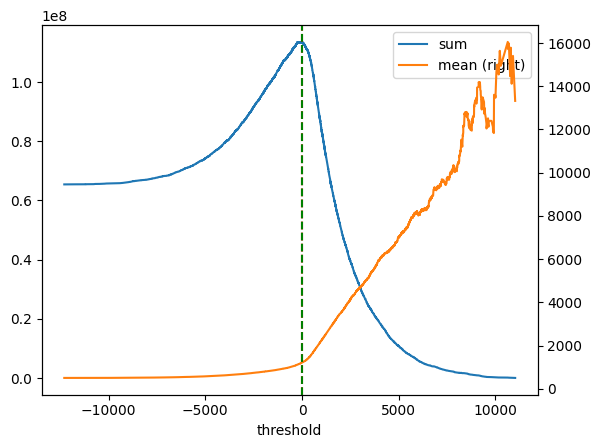

In [34]:
lgb_prediction = lgb_model.predict(X_test)
lgb_curve = build_curve(y_test, lgb_prediction)
plot_curve(lgb_curve)

Interestingly, the threshold is closer to 0, than in XGBoost, possibly model is better at predicting small absolute values. Lift is slightly better, but not too much. Still, LightGBM provides better speed, so it is prefered.

In [35]:
print(f"Train rmse=${root_mean_squared_error(lgb_model.predict(X_train), y_train)}")
print(f"Test rmse=${root_mean_squared_error(lgb_prediction, y_test)}")

Train rmse=$4892.067841150849
Test rmse=$4925.760565907445


In [36]:
print(f"Train r2={r2_score(y_train, lgb_model.predict(X_train))}")
print(f"Test r2={r2_score(y_test, lgb_prediction)}")

Train r2=0.15041324059329286
Test r2=0.1174707630234535


Model explains 11.7% (compared to 10.9% of XGBoost) of variance on test dataset and has a prediction error of around $4925 ($23 improvement compared to XGBoost). 

In [48]:
pd.Series(
    lgb_model.booster_.feature_importance(importance_type='gain'),
    index=X_train.columns
).sort_values(ascending=False).head(20)

issue_y                 4.318367e+13
loan_amnt               3.878760e+13
term                    2.338840e+13
addr_state              9.019271e+12
all_util                7.483079e+12
acc_open_past_24mths    7.345752e+12
zip_code                6.903993e+12
max_bal_bc              6.097576e+12
annual_inc              5.998417e+12
mort_acc                4.963356e+12
issue_m                 4.957665e+12
revol_bal               4.689980e+12
dti                     4.346955e+12
home_ownership          4.253448e+12
tot_hi_cred_lim         3.327265e+12
mo_sin_old_rev_tl_op    3.207790e+12
mths_since_rcnt_il      3.206039e+12
open_rv_24m             3.176124e+12
total_bc_limit          2.787968e+12
fico_range_low          2.770763e+12
dtype: float64

Model seems to prioritise categorical splits more, as it has a better support for them compared to XGBoost. Loan amount, term, state and zip_code seem to play a bigger role, probably due to leaf-wise growth, extracting deeper splits. Those makes sense, since loan amount directly contributes to the possible return, term affects chances of default during the loan lifetime, and region can represent economic conditions of a certain area. Interestingly, even issue month has some predictive power.

Text(0, 0.5, 'prediction')

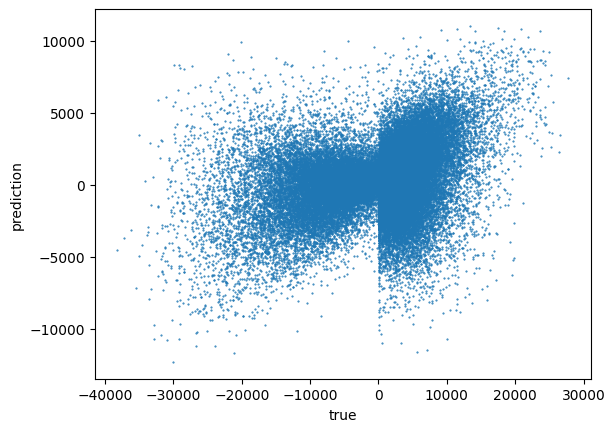

In [38]:
plt.plot(y_test, lgb_prediction, 'o', markersize=0.5)
plt.xlabel('true')
plt.ylabel('prediction')

Text(0, 0.5, 'residuals')

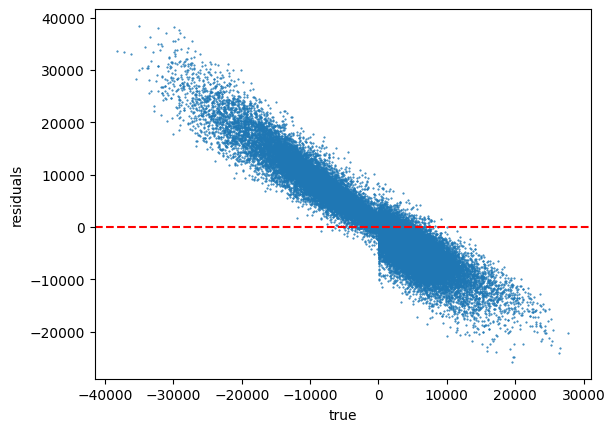

In [39]:
plt.plot(y_test, lgb_prediction - y_test, 'o', markersize=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('true')
plt.ylabel('residuals')

Not surprisingly, model still predicts towards the mean, and still it leads to 1.73 times increase in revenue.

Clearly, LightGBM is more accurate and efficient, and should be used as upper limit for regression.

## Decision tree

Let's continue with using simple decision tree as a regressor. They are less predictive, but simple and interpretable. Comparing them with established upper limit can prompt their usage, maybe not necessarily as a predictor, but as a clear visual explainer. 

CART is the most popular algorithm for building decision tress. It is fast and greedy, making it ideal for ensembles. It grows level-wise choosing the most promising, yet possibly not globally optimal, split. After the tree is built, pruning can be used to remove branches that introduce more complexity than the amount of impurity reduction, preventing overfitting.

When tuning the model, it's nice to have one hyperparameter that controls overfitting. In boosting models we used number of estimators. Here ccp_alpha is such a parameter. We can build deep trees, and then prune non-promising branches until we achieve stability, without the need to tune other pre-pruning parameters. They are good proxies, but not as good as ccp_alpha. Besides, pruning allows to discover better splits, which would be lost if the tree was greedily built with shallow depth. 

Sklearn implementation doesn't support categoricals natively, so we will need to encode them using one-hot encoding. h2o natively suppports categorical variables in decision trees, but requires more overhead, so we won't use it. Variables with 50+ categories should be encoded using target encoding to save space. Ideally, each split should be encoded separately to reduce leakage, but in order to reduce training time we will encode categorical variables before. Those variables don't seem to have very big predictive power, so hopefully the effect of leakage will be reduced. 

In [20]:
categorical = X_train.select_dtypes(include='category').nunique()
one_hot_cols = categorical[categorical < 50].index.tolist()
target_cols = categorical[categorical >= 50].index.tolist()
print(one_hot_cols)
print(target_cols)

['home_ownership', 'purpose', 'zip_region']
['emp_title', 'zip_code', 'addr_state']


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), one_hot_cols),
    ('target', TargetEncoder(), target_cols)
], remainder='passthrough', force_int_remainder_cols=False)

X_train_encoded = pd.DataFrame(preprocessor.fit_transform(X_train, y_train), columns=preprocessor.get_feature_names_out())
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1162575 entries, 0 to 1162574
Columns: 112 entries, ohe__home_ownership_ANY to remainder__total_il_high_credit_limit
dtypes: object(112)
memory usage: 993.4+ MB


In [19]:
from sklearn.tree import DecisionTreeRegressor

cart_model = DecisionTreeRegressor(random_state=42, max_depth=15)
cart_model.fit(X_train_encoded, y_train)

DecisionTreeRegressor(max_depth=15, random_state=42)

In [22]:
X_test_encoded = pd.DataFrame(preprocessor.transform(X_test), columns=preprocessor.get_feature_names_out())

In [21]:
print("Train RMSE:", root_mean_squared_error(y_train, cart_model.predict(X_train_encoded)))
y_pred = cart_model.predict(X_test_encoded)
print("Test RMSE:", root_mean_squared_error(y_test, y_pred))

Train RMSE: 4475.806508129271
Test RMSE: 5451.027636440432


Threshold: 138.2462
Lift: 1.4772 times
Net improvement: $9.660405e+07 - $6.539672e+07 = $3.120733e+07


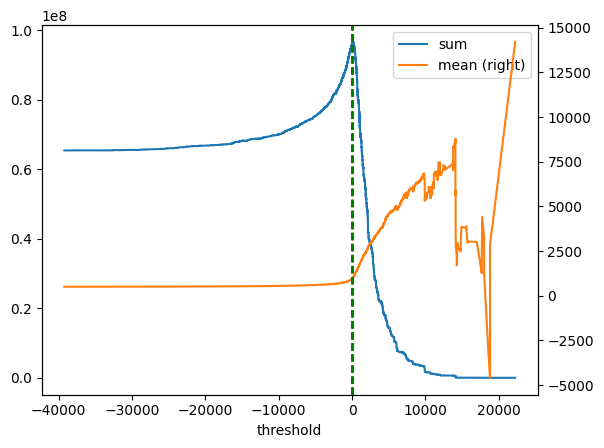

In [22]:
cart_curve = build_curve(y_test, y_pred)
plot_curve(cart_curve)

Classic case of overfitting, judging from the disparity between train and test RMSE. We already see that it requires some time to build one decision tree of max depth 15, so when doing cross-validation we will need to use a subset. Now let's get the range of productive cpp_alphas:

In [ ]:
path = cart_model.cost_complexity_pruning_path(X_train_encoded, y_train)
path

{'ccp_alphas': array([0.00000000e+00, 4.74162957e-07, 2.39320606e-06, ...,
        2.47249920e+05, 2.51988852e+05, 6.85543905e+05]),
 'impurities': array([20017536.011595  , 20017536.01159547, 20017536.01159786, ...,
        27231841.93931444, 27483830.79122877, 28169374.69592268])}

<Axes: xlabel='ccp_alphas'>

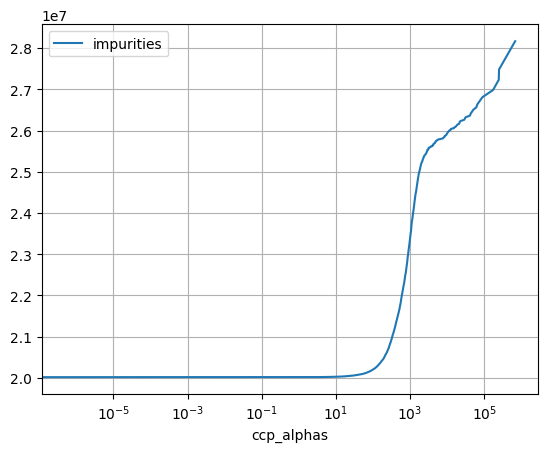

In [28]:
pd.DataFrame(path).plot(x='ccp_alphas', y='impurities', logx=True, grid=True)

<Axes: xlabel='ccp_alphas'>

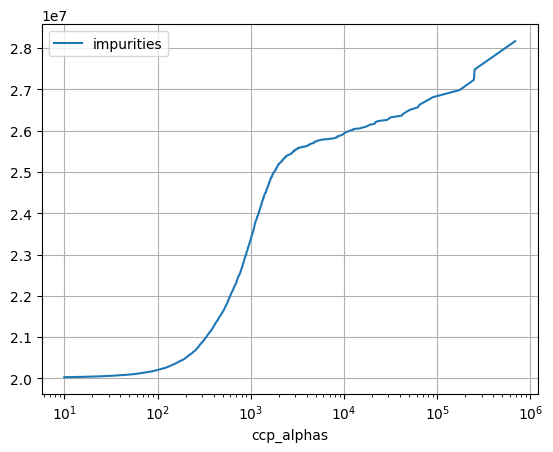

In [31]:
pd.DataFrame(path).query('ccp_alphas > 10').plot(x='ccp_alphas', y='impurities', logx=True, grid=True)

### CART: model tuning
Let's see how train and test metrics change with the change of ccp_alpha

In [ ]:
from sklearn.model_selection import cross_validate
ccp_alphas = np.logspace(1, 6, num=30)
result_dfs = []
for alpha in ccp_alphas:
    print(alpha)
    model = DecisionTreeRegressor(ccp_alpha=alpha, max_depth=15)
    cv_result = cross_validate(model, X_train_encoded, y_train, cv=5, scoring={'lift': lift_scorer, 'neg_mean_squared_error': 'neg_mean_squared_error', 'r2': 'r2'}, return_estimator=True, return_train_score=True)
    cv_result['depth'] = [est.get_depth() for est in cv_result['estimator']]
    del cv_result['estimator']
    result = pd.DataFrame(cv_result)
    result['alpha'] = alpha
    result_dfs.append(result)

10.0
14.873521072935118
22.122162910704493
32.90344562312668
48.93900918477494
72.78953843983153
108.2636733874054
161.02620275609394
239.5026619987486
356.2247890262444
529.8316906283712
788.0462815669912
1172.1022975334806
1743.328822199989
2592.943797404667
3856.620421163472
5736.152510448682
8531.678524172814
12689.610031679234
18873.918221350996
28072.162039411814
41753.18936560409
62101.694189156166
92367.08571873866
137382.37958832638
204335.9717856944
303919.5382313201
452035.365636025
672335.7536499335
1000000.0


In [103]:
pd.concat(result_dfs).groupby('alpha').agg(['mean', 'std']).sort_values(('test_lift', 'mean'), ascending=False).head(20)

fit_time            score_time           test_lift            \
                   mean        std       mean       std      mean       std   
alpha                                                                         
2592.943797   65.536431   7.843711   0.878529  0.080192  1.653314  0.015565   
3856.620421   59.429567   0.390207   0.793227  0.053732  1.648497  0.016867   
5736.152510   60.131163   0.471176   0.786025  0.037231  1.640692  0.012762   
1743.328822   65.722175  10.483538   0.965678  0.194689  1.640214  0.012304   
8531.678524   60.144069   0.433824   0.787050  0.026267  1.638016  0.014641   
12689.610032  60.244115   1.148689   0.778564  0.039586  1.634749  0.012096   
18873.918221  59.600818   0.444285   0.856170  0.094754  1.629186  0.017136   
28072.162039  61.608561   1.395467   0.826767  0.047345  1.619833  0.015641   
1172.102298   60.199027   2.194143   0.823878  0.032384  1.609543  0.013431   
788.046282    60.760414   1.045498   0.832780  0.046985  1.583447  0.012939   
529.831691    62.263681   3.089763   0.858753  0.123952  1.567711  0.016039   
41753.189366  59.668977   0.597660   0.788083  0.049764  1.559256  0.016431   
356.224789    59.786025   2.658112   0.801208  0.047048  1.546090  0.016192   
239.502662    59.008897   0.213353   0.801245  0.040775  1.529155  0.014045   
161.026203    58.613214   0.464551   0.833840  0.042576  1.521012  0.015437   
72.789538     58.808785   0.415402   0.830826  0.026197  1.518301  0.014295   
108.263673    58.887848   1.296559   0.808981  0.047867  1.517310  0.013236   
48.939009     60.877375   5.959770   0.856944  0.088882  1.516386  0.014934   
22.122163     58.206034   0.657955   0.809214  0.015459  1.515304  0.016461   
32.903446     58.925405   2.512488   0.818142  0.051625  1.514950  0.016303   

             train_lift           test_neg_mean_squared_error                 \
                   mean       std                        mean            std   
alpha                                                                          
2592.943797    1.679582  0.004667               -2.582748e+07   58989.219933   
3856.620421    1.658318  0.006192               -2.578118e+07   45688.480289   
5736.152510    1.647816  0.006667               -2.585694e+07   39850.137283   
1743.328822    1.724655  0.003551               -2.639511e+07   81742.649933   
8531.678524    1.642754  0.005437               -2.591217e+07   43529.870723   
12689.610032   1.638788  0.005409               -2.601754e+07   31345.246355   
18873.918221   1.633298  0.003952               -2.617690e+07   49538.216585   
28072.162039   1.621474  0.011633               -2.625482e+07   34579.561607   
1172.102298    1.808155  0.006481               -2.756694e+07  217382.628107   
788.046282     1.885988  0.009200               -2.854584e+07  183984.156958   
529.831691     1.950849  0.013849               -2.926766e+07  235946.862883   
41753.189366   1.557519  0.004398               -2.635810e+07   39598.352789   
356.224789     2.012279  0.015893               -2.985430e+07  275245.167885   
239.502662     2.051594  0.015084               -3.022938e+07  252632.514148   
161.026203     2.080264  0.014409               -3.041495e+07  214599.342285   
72.789538      2.107180  0.015543               -3.060825e+07  238040.195514   
108.263673     2.095976  0.015117               -3.058294e+07  237992.627578   
48.939009      2.113155  0.015288               -3.067471e+07  242383.049804   
22.122163      2.118468  0.015504               -3.070629e+07  240020.783772   
32.903446      2.116099  0.015544               -3.073238e+07  248867.391037   

             train_neg_mean_squared_error                  test_r2            \
                                     mean            std      mean       std   
alpha                                                                          
2592.943797                 -2.526955e+07   56837.813849  0.083129  0.003396   
3856.620421                 -2.55660

<Axes: xlabel='alpha'>

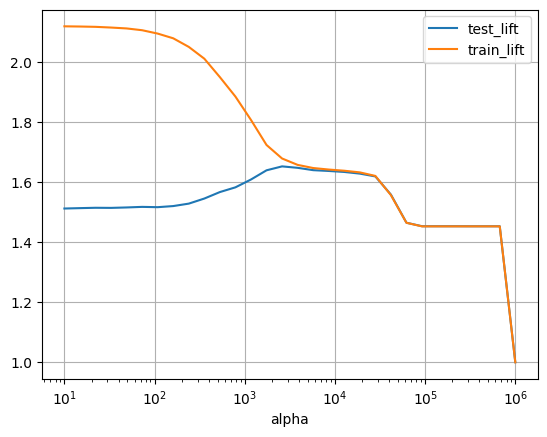

In [106]:
pd.concat(result_dfs).groupby('alpha').agg('mean').plot(y=['test_lift', 'train_lift'], logx=True, grid=True)

<Axes: xlabel='alpha'>

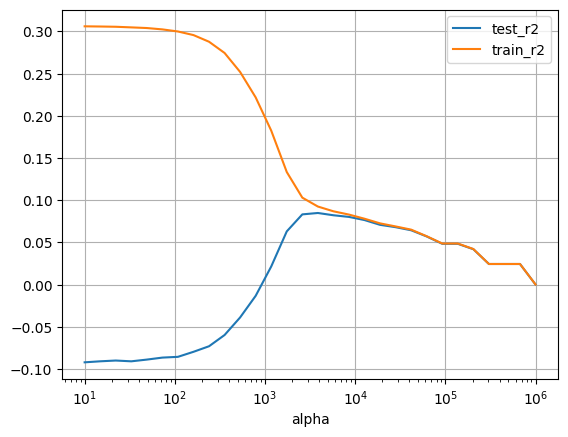

In [101]:
pd.concat(result_dfs).groupby('alpha').agg('mean').plot(y=['test_r2', 'train_r2'], logx=True, grid=True)

<Axes: xlabel='alpha'>

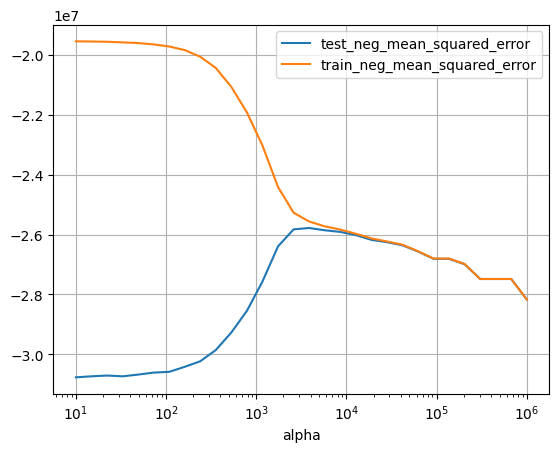

In [102]:
pd.concat(result_dfs).groupby('alpha').agg('mean').plot(y=['test_neg_mean_squared_error', 'train_neg_mean_squared_error'], logx=True, grid=True)

<Axes: xlabel='alpha'>

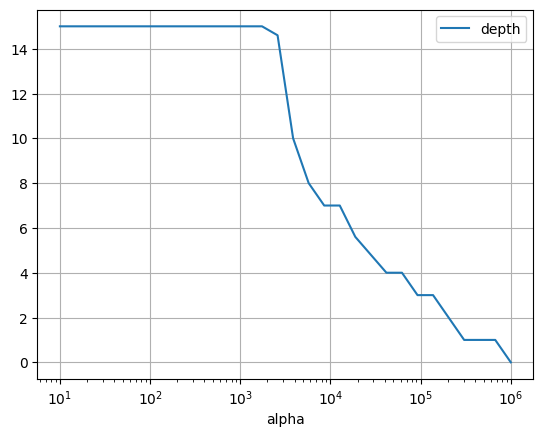

In [104]:
pd.concat(result_dfs).groupby('alpha').agg('mean').plot(y=['depth'], logx=True, grid=True)

Around alpha=5000 train and test scores converge, but the test metric doesn't yet deteriorate due to model simplicity - bias-variance tradeoff in action, clearly observable through a single hyperparameter. At this alpha average depth is around 8. The model preserves predictive power judging by RMSE until around alpha=10,000, but lift only starts to decline sharply around alpha=30,000, corresponding to average depths of 7 and 5. For interpretability we choose not the highest test lift of 1.65 at depth 14.6, but the third best with lift 1.64 at average depth 8 — a negligible difference in performance for a substantial gain in simplicity.

### CART: model evaluation

In [ ]:
model = DecisionTreeRegressor(ccp_alpha=5_000, random_state=42, max_depth=15)
cv_result = cross_validate(model, X_train_encoded, y_train, cv=5, scoring={'lift': lift_scorer, 'neg_mean_squared_error': 'neg_mean_squared_error', 'r2': 'r2'}, return_estimator=True, return_train_score=True)
cv_result['depth'] = [est.get_depth() for est in cv_result['estimator']]
del cv_result['estimator']
cv_result = pd.DataFrame(cv_result)
cv_result

,fit_time,score_time,test_lift,train_lift,test_neg_mean_squared_error,train_neg_mean_squared_error,test_r2,train_r2,depth
0,78.074506,1.034894,1.644566,1.649953,-2.585180e+07,-2.567135e+07,0.086763,0.087557,8
1,81.756976,0.994343,1.617757,1.653187,-2.580558e+07,-2.568542e+07,0.083259,0.088341,8
2,90.374405,1.366410,1.640690,1.656439,-2.585588e+07,-2.567080e+07,0.079564,0.089332,8
3,77.036727,0.879125,1.659086,1.648217,-2.575569e+07,-2.568798e+07,0.085374,0.088166,8
4,74.972111,1.072674,1.650510,1.647385,-2.588127e+07,-2.567614e+07,0.080231,0.088755,8


In [116]:
cv_result['test_rmse'] = (-cv_result['test_neg_mean_squared_error']) ** 0.5
cv_result['train_rmse'] = (-cv_result['train_neg_mean_squared_error']) ** 0.5
cv_result.agg(['mean', 'std'])

,fit_time,score_time,test_lift,train_lift,test_neg_mean_squared_error,train_neg_mean_squared_error,test_r2,train_r2,depth,test_rmse,train_rmse
mean,80.442945,1.069489,1.642522,1.651036,-2.583004e+07,-2.567834e+07,0.083038,0.088430,8.0,5082.324566,5067.379905
std,6.072529,0.181145,0.015484,0.003751,4.973040e+04,7.961431e+03,0.003135,0.000663,0.0,4.893750,0.785543


Lift is quite decent, compared to the upper limit. Possibly there is so little signal that even single tree explains most of the variance. This finding certainly can influence the choice of the model. If not used as a primary model, we still can use it as a nice simple interpretable model for non-technical stakeholders.

### CART: final evaluation

In [23]:
model = DecisionTreeRegressor(random_state=42, max_depth=20, ccp_alpha=5_000)
model.fit(X_train_encoded, y_train)
model.get_depth()

8

In [24]:
y_pred = model.predict(X_test_encoded)
y_pred_train = model.predict(X_train_encoded)
print("Train lift:", lift_score(y_train, y_pred_train))
print("Test lift:", lift_score(y_test, y_pred))

Train lift: 1.6473053788234047
Test lift: 1.5882682686443124


In [25]:
print("Train RMSE:", root_mean_squared_error(y_train, y_pred_train))
print("Test RMSE:", root_mean_squared_error(y_test, y_pred))

Train RMSE: 5073.1107760242885
Test RMSE: 5026.308345232905


In [26]:
from sklearn.metrics import r2_score
print(f"Train r2={r2_score(y_train, y_pred_train)}")
print(f"Test r2={r2_score(y_test, y_pred)}")

Train r2=0.08636761647609992
Test r2=0.08107353038401943


Threshold: 57.0047
Lift: 1.5883 times
Net improvement: $1.038675e+08 - $6.539672e+07 = $3.847082e+07


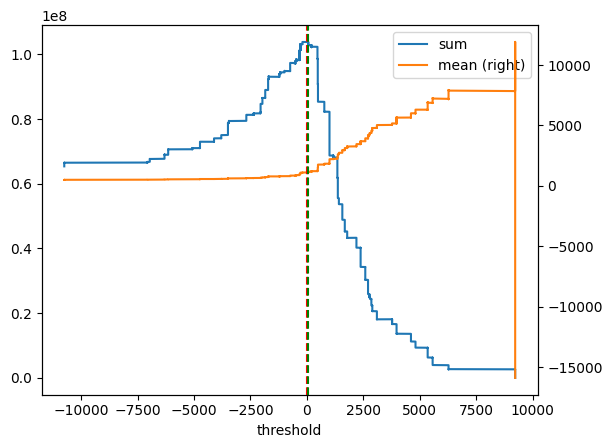

In [28]:
cart_curve = build_curve(y_test, y_pred)
plot_curve(cart_curve)

8 levels are still quite interpretable, train and test RMSE are comparable, and we get an improvement of 1.588 times. Lower than 1.73 times in boosting models, but it's quite surprising how such a simple model can give the majority of improvement. 

Text(0, 0.5, 'predicted')

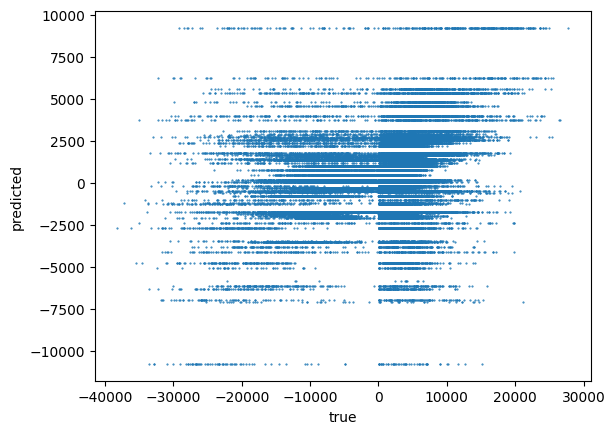

In [128]:
plt.plot(y_test, y_pred, 'o', markersize=0.5)
plt.xlabel('true')
plt.ylabel('predicted')

Text(0, 0.5, 'residuals')

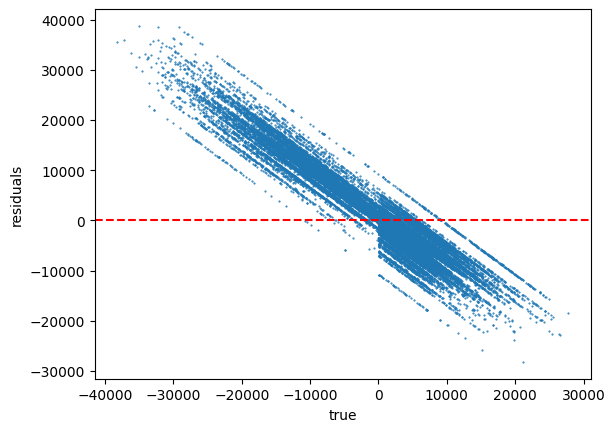

In [129]:
plt.plot(y_test, y_pred - y_test, 'o', markersize=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('true')
plt.ylabel('residuals')

Residuals represent the way decision tree work. 

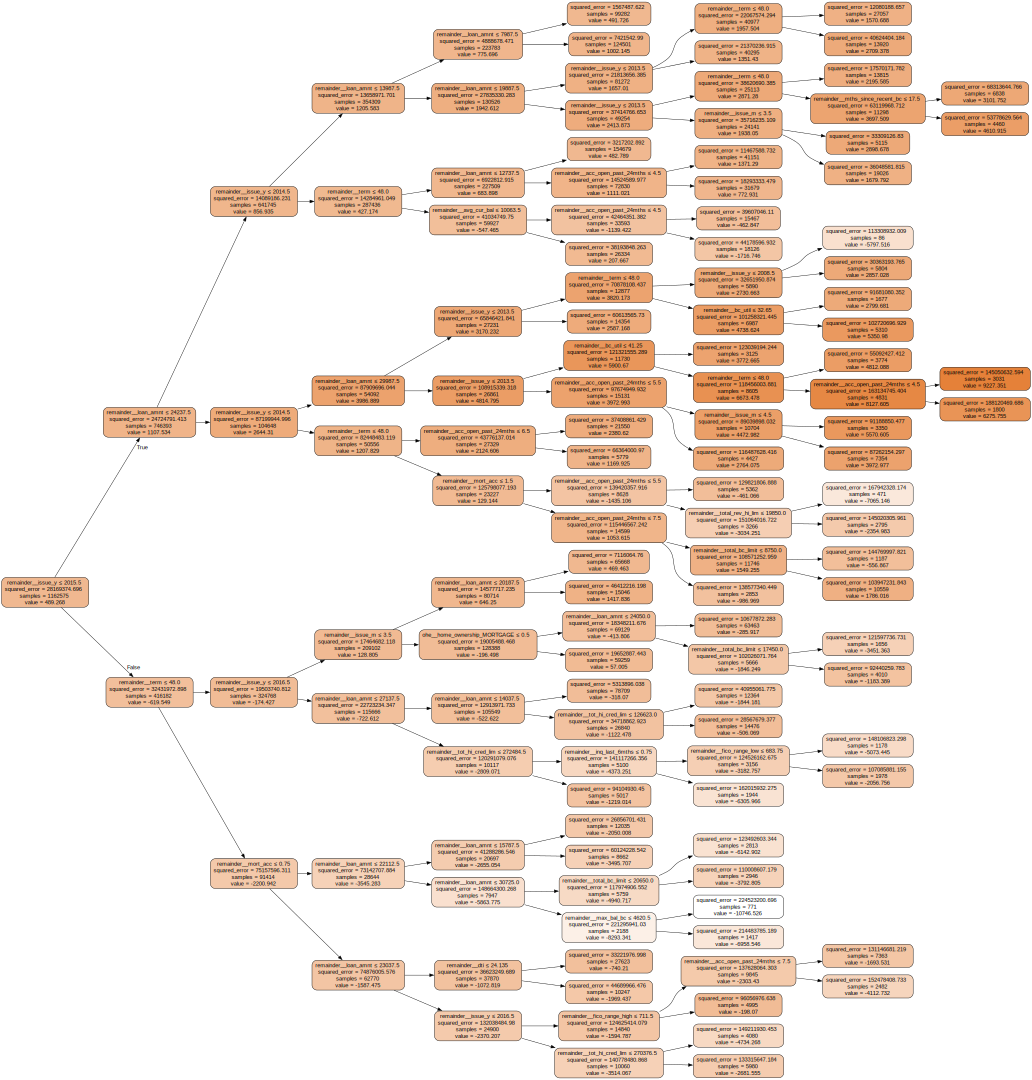

In [131]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(model,
                           max_depth=8,
                           feature_names=X_train_encoded.columns,
                           filled=True,
                           rounded=True,
                           special_characters=True)

dot_data = dot_data.replace('digraph Tree {', 'digraph Tree {\nrankdir=LR;\nsize="15!"; ratio=compress;')
graph = graphviz.Source(dot_data)
graph

Issue year, loan amount and term seem to explain the most of the variance. Number of mortage accounts, issue month, average current balance, dti, credit limit and mortgage type of home ownership follow. The lowest return of -10k is associated with 5-year loans issued after 2015 with amounts higher than $30k to borrowers with no mortgage accounts and maximum current balanced owed on all revolving accounts lower than 4620. The highest returns of $9k on average is associated with 5-year loans issued before 2013 with amounts higher than 30k to borrowers with credit card utilization higher than 41% and number of trades opened in the past 24 months lower than 4. We won't follow this path going predicting new loans, but it's interesting to see such history.

# Future work
On the topic of a simple single decision tree, it would be interesting to compare XGBoost and LightGBM single tree models. XGBoost is interesting because of its built-in split evaluation during tree construction and regularization, LightGBM is interesting not only for its speed, but also for its expansion through leaves, capable of discovering more promising paths.  

Globall optimal and casual inference trees are promising, since they rely on other methods besides simple greedy search and aim to find the global optimum. Though they are computationally expensive. M5 regression trees can extract some additional accuracy by having linear regressions at leaves, rather than mean point estimates.

Random forest is an ensemble method aiming at reducing variance of base models by averaging out their predictions. Theoretically it can allow to have more complex predictors, as their variance is going to be reduced. Unlike classical bagging, random subsampling in columns is used to decorrelate the trees and allow them to discover different relationships, not only the most promising. Overall it sits in a middleground between low bias boosting models and simple interpretable models, so their usage is somewhat limited.